# Predicting Heart Disease

**Introduction**
The World Health Organization (WHO) estimates that 17.9 million people die from cardiovascular diseases (CVDs) every year. Identifying these risk factors early on could help prevent many premature deaths.
In this project, we are tasked with using the health dataset to accurately predict the likelihood of a new patient having heart disease in the future.

**Dataset**
The dataset includes relevant information for each patient, such as their personal information and some medical data. The dataset has the following features:
- <font color="red">Age: the age of the patient.</font>
- <font color="blue">Sex: the sex of the patient.</font>
- <font color="blue">ChestPainType: four types of chest pain.</font>
- <font color="blue">RestingBP: resting blood pressure.</font>
- <font color="red">Cholesterol: serum cholesterol.</font>
- <font color="red">FastingBS: fasting blood sugar.</font>
- <font color="blue">RestingECG: three types of resting electrocardiogram.</font>
- <font color="red">MaxHR: maximum heart rate achieved.</font>
- <font color="blue">ExerciseAngina: exercise-induced angina.</font>
- <font color="red">Oldpeak: ST [Numeric value measured in depression].</font>
- <font color="blue">ST_Slope: the slope of the peak exercise ST segment.</font>
- <font color="blue">HeartDisease: output class.</font>

(Note: red color indicates a numerical column, blue color indicates a categorical column.)



In [12]:
import pandas as pd

df = pd.read_csv('heart_disease_prediction.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


**Note** that we have a total of 12 features (columns).
The object data type is usually a string, which corresponds to categorical columns. However, **RestingBP and HearDisease**, although they have the data type int64, are also categorical variables since they only take the values 0 and 1.

We will start by exploring and analyzing the numerical columns.

In [14]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


From the statistical summary, we can see that the average age of the patients is 54.
The minimum values for **RestingBP, Cholesterol** is 0, which doesn't make sense.
The most likely explanation is that these are missing values and were filled with 0.
According to American Heart Association, serum cholesterol is "a composite of different measurements. Your total blood cholesterol is calculated by adding your HDL and LDL cholesterol levels, plus 20% of your triglyceride level". The information is enough to let us know that a 0 value for serum cholesterol is unlikely.

The median for **Cholesterol** is higher than its mean by roughly 25 units, indicating that is could be a **left-skewed distribution** with a possibility of outliers skewing the distribution.

Next, we will try to find out the number of missing values in RestingBP and Cholesterol columns, which are rows filled with integer 0.

In [15]:
RestingBP_countMissing = (df['RestingBP'] == 0).sum()
Cholesterol_countMissing = (df['Cholesterol'] == 0).sum()
print(f"Number of missing values in RestingBP: {RestingBP_countMissing}")
print(f"Number of missing values in Cholesterol: {Cholesterol_countMissing}")

Number of missing values in RestingBP: 1
Number of missing values in Cholesterol: 172


Then, we can start exploring categorical columns with the help of histogram.

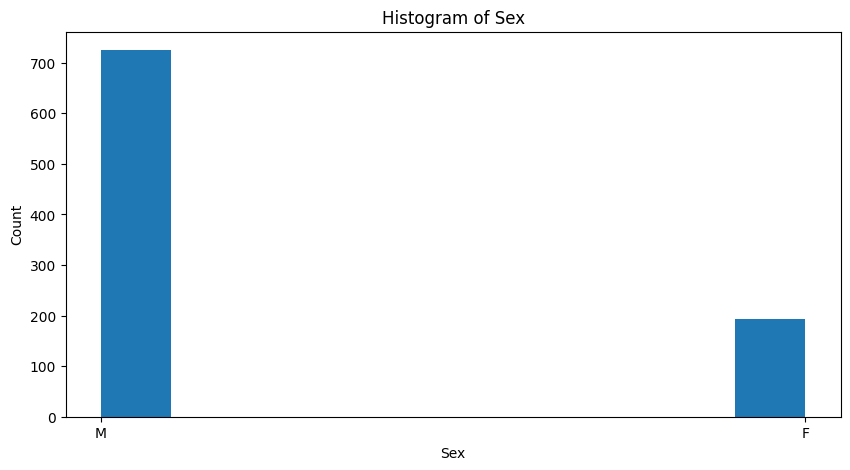

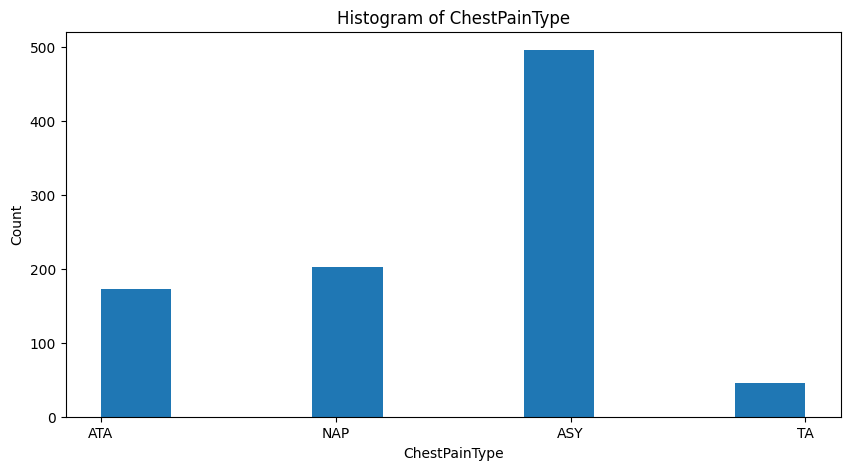

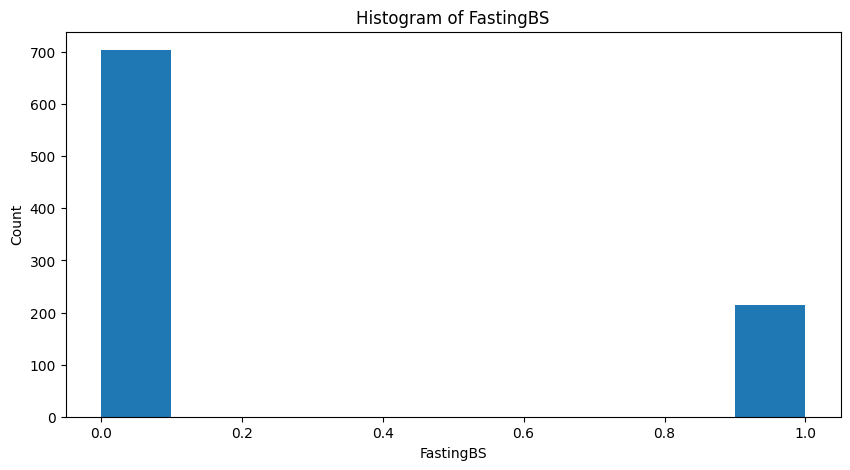

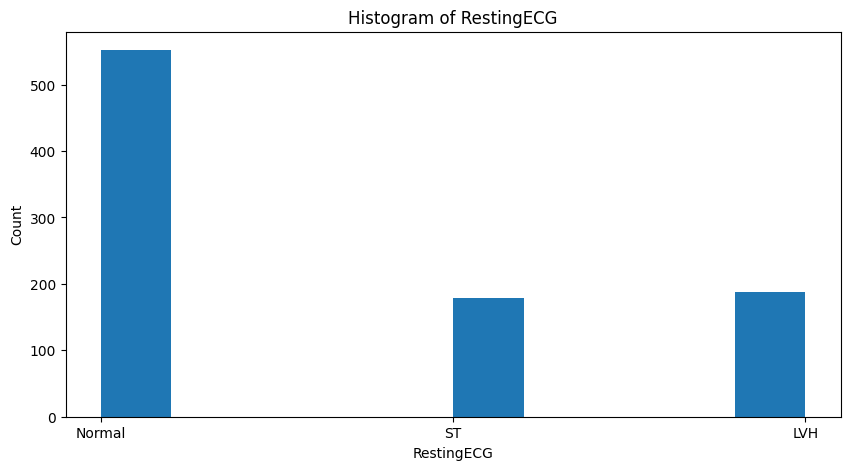

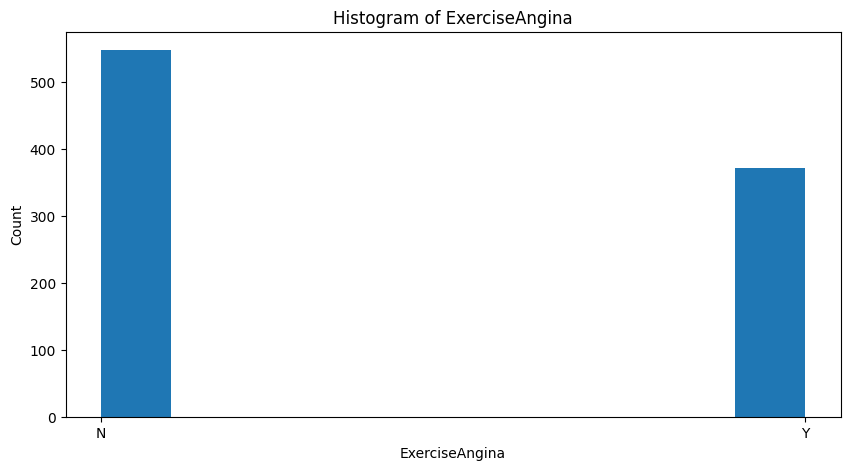

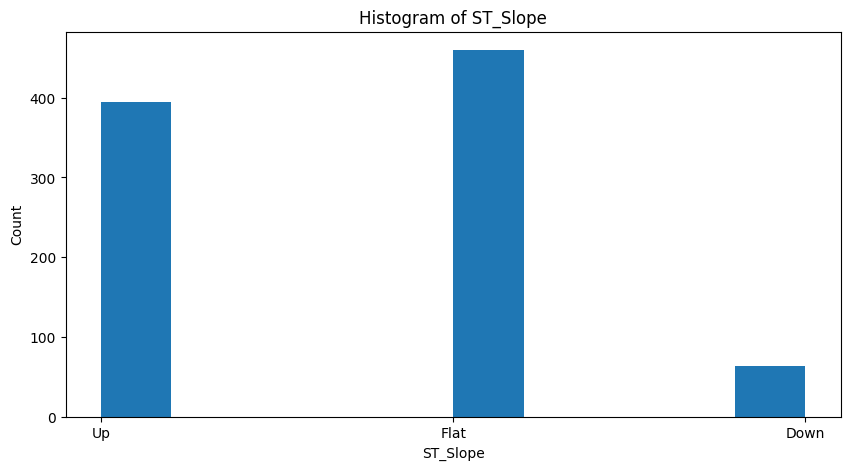

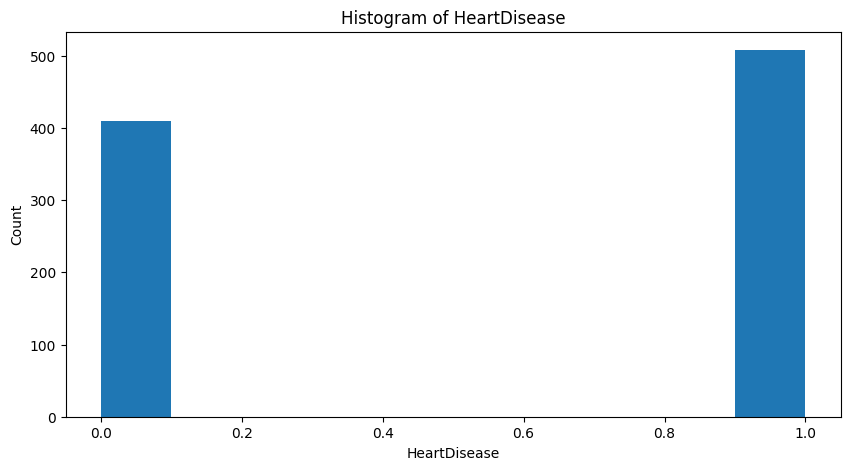

In [16]:
import matplotlib.pyplot as plt

def plot_histogram(column_name):
    plt.figure(figsize=(10, 5))
    plt.title(f'Histogram of {column_name}')
    plt.hist(df[column_name])
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.show()


plot_histogram('Sex')
plot_histogram('ChestPainType')
plot_histogram('FastingBS')
plot_histogram('RestingECG')
plot_histogram('ExerciseAngina')
plot_histogram('ST_Slope')
plot_histogram('HeartDisease')

1. It can be seen from the graph that more than **700** patients are male, while only around **200** patients are female. It may lead to a gender bias on the study.
2. In addition, most of the chest pain type is **ASY**, which is significant higher than the other types. 
3. FastingBS and Resting ECG are mostly **0** and **normal**, respectively. 
4. The **'Down' slope** in ST_Slope is rare.
5. **More than half** of the people in the dataset have **heart disease**.

Next, let's divide the data even further, by categorying each domain of a column based on the heart disease to show if they have a strong relationship.

In [22]:
def plot_grouped_histogram(column_name):
    # Get counts grouped by the column and HeartDisease
    grouped = df.groupby([column_name, 'HeartDisease']).size().unstack(fill_value=0)

    # Plot the grouped bar chart
    grouped.plot(kind='bar', stacked=True, figsize=(10, 5))

    # Add labels and formatting
    plt.xlabel(column_name)
    plt.ylabel('Number of Patients')
    plt.title(f'{column_name} Distribution Grouped by Heart Disease')
    plt.legend(['No Heart Disease', 'Heart Disease'], title='Heart Disease')
    plt.show()

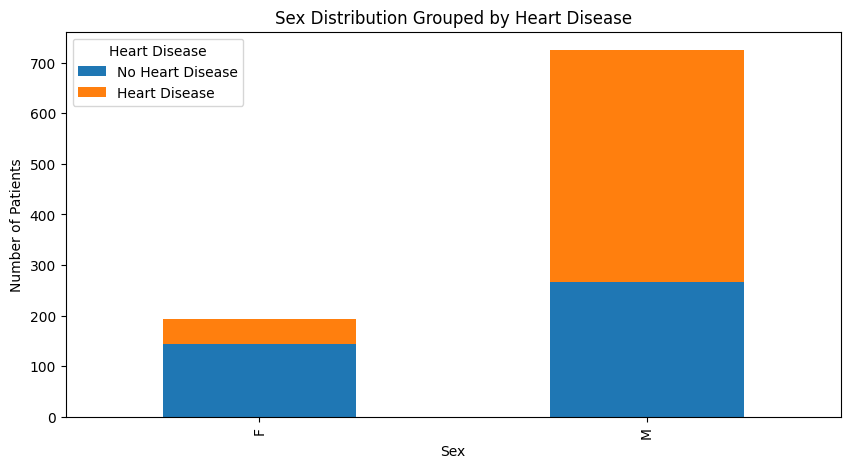

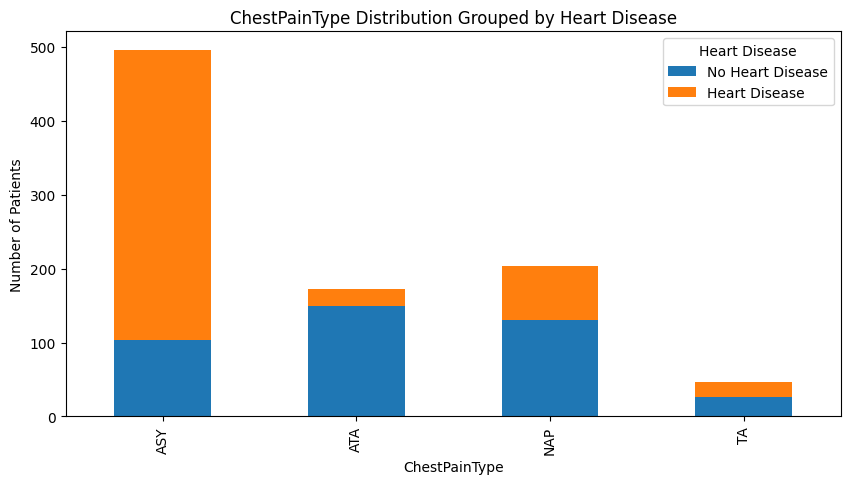

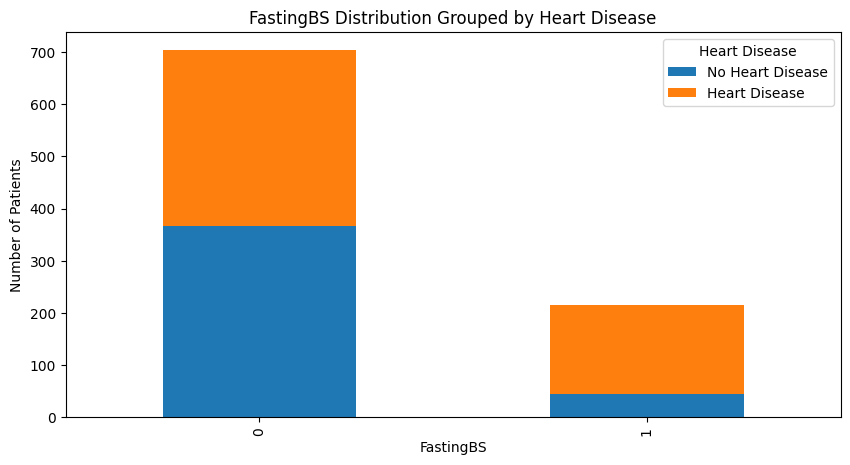

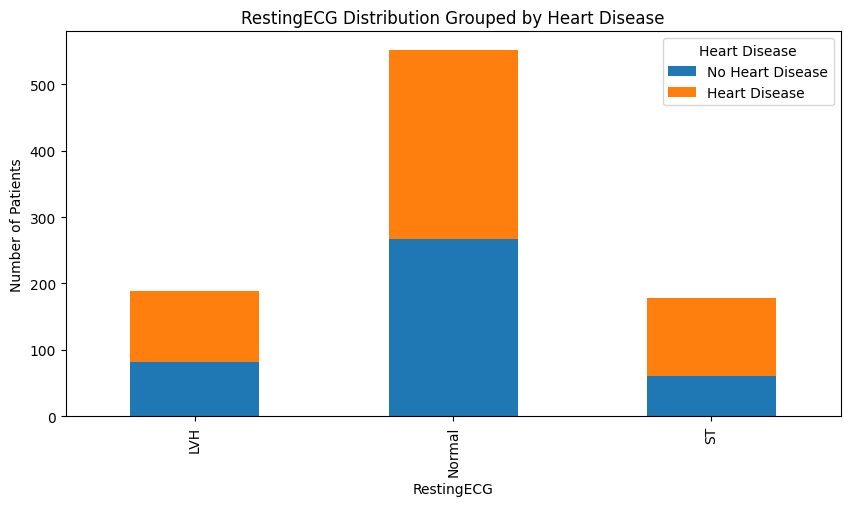

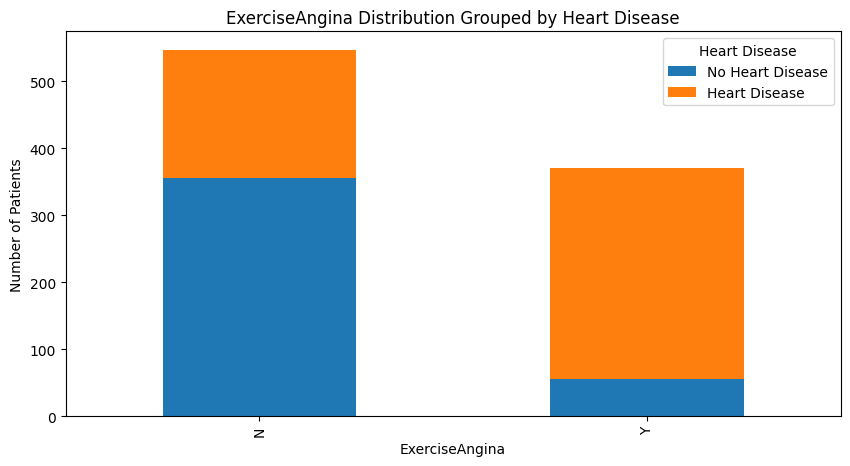

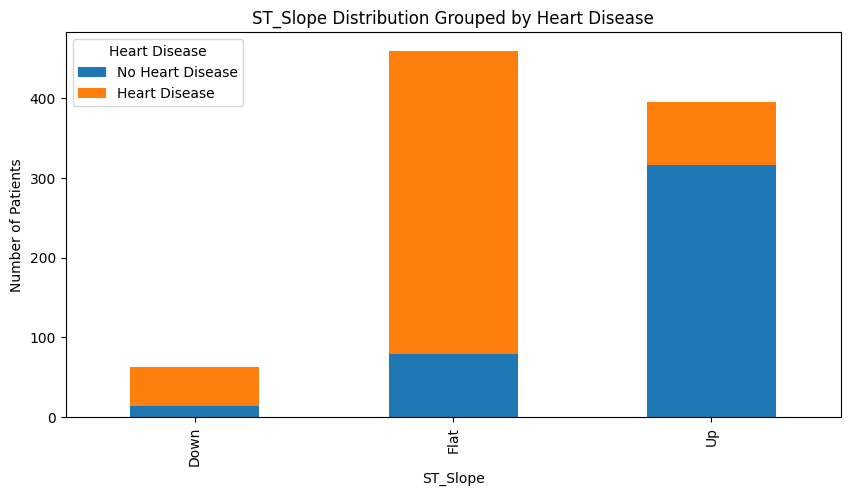

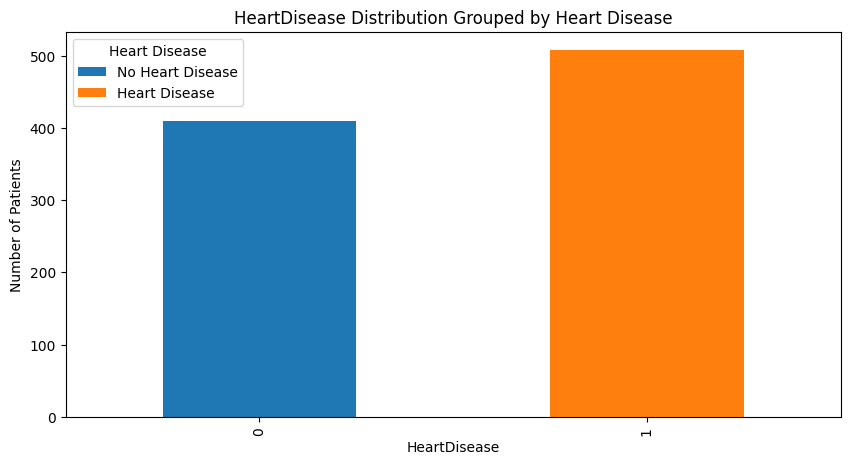

In [23]:
plot_grouped_histogram('Sex')
plot_grouped_histogram('ChestPainType')
plot_grouped_histogram('FastingBS')
plot_grouped_histogram('RestingECG')
plot_grouped_histogram('ExerciseAngina')
plot_grouped_histogram('ST_Slope')
plot_grouped_histogram('HeartDisease')

1. It can be seen from the grouped histogram that **males** have significantly more counts with heart disease, and the **ASY chest pain** is where the vast majority heart disease cases reside. 
2. Moreover, patients with fasting blood sugar **greater than 120 mg/dl** have a much more percentage with heart disease.
3. Similarly, patients with ExerciseAngina marked as **'YES'** have far more cases than those without.
4. Lastly, patients with ST slope classified as **'Down' or 'Flat'** also appear to have a higher likelihood of heart disease compared to those with an 'Up' slope.